In [3]:
import pandas as pd
df_fish = pd.read_csv('C:\\Users\\t2011\\Desktop\\Peso de Peces\\Fish.csv')
df_fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


### nulos (no hay)

In [4]:
print(df_fish.isnull().sum())

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64


conteo de valores unicos en 'species'

In [5]:
print(df_fish['Species'].value_counts())

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64


### convertir Texto a numeros (One Hot Encoding) - Columna: 'Species'

In [6]:
df_encoded = pd.get_dummies(
    df_fish,
    columns=['Species'],
    dtype=int,
    drop_first=True
)
df_encoded.head()

,Weight,Length1,Length2,Length3,Height,Width,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
0,242.0,23.2,25.4,30.0,11.5200,4.0200,0,0,0,0,0,0
1,290.0,24.0,26.3,31.2,12.4800,4.3056,0,0,0,0,0,0
2,340.0,23.9,26.5,31.1,12.3778,4.6961,0,0,0,0,0,0
3,363.0,26.3,29.0,33.5,12.7300,4.4555,0,0,0,0,0,0
4,430.0,26.5,29.0,34.0,12.4440,5.1340,0,0,0,0,0,0


### Separacion Caracterisiticas (X) de etiqueta (y)

In [7]:
X = df_encoded.drop(columns=['Weight'])
y = df_encoded['Weight']

### Train Test Split

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(127, 11)
(32, 11)
(127,)
(32,)


### Escalado

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
col_names = X.columns.tolist()

In [11]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = col_names)

# Seleccion de caracteristicas

### RFE

 modelo de regresión 'Ridge' para  RFECV


In [12]:
from sklearn.linear_model import Ridge
rfecv_model = Ridge()
rfecv_model

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [13]:
from sklearn.feature_selection import RFECV
rfecv = RFECV(
    estimator = rfecv_model,
    step =  1,
    cv = 7,
    scoring = 'r2',
    min_features_to_select=1,
    n_jobs=-1
)
rfecv.fit(X_train_scaled, y_train)


,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,Ridge()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",7
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'r2'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True


Características seleccionadas por RFECV

In [14]:
print(f"Número óptimo de características seleccionadas por RFECV: {rfecv.n_features_}")
features_rfecv = X_train_scaled.columns[rfecv.support_].tolist()
features_rfecv

Número óptimo de características seleccionadas por RFECV: 5


['Length1', 'Length2', 'Length3', 'Species_Pike', 'Species_Smelt']

### Matriz de Correlación CHECAR!

In [15]:
df_corr =  X_train_scaled.copy()
df_corr['Weight'] = y_train.values

In [16]:
corr_matrix = df_corr.corr()
corr_matrix

,Length1,Length2,Length3,Height,Width,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish,Weight
Length1,1.000000,0.999572,0.992265,0.600599,0.854407,-0.219894,-0.026989,0.589730,-0.242422,-0.408416,0.047595,0.918787
Length2,0.999572,1.000000,0.994223,0.614982,0.860071,-0.220706,-0.025554,0.580181,-0.247837,-0.419327,0.049945,0.921256
Length3,0.992265,0.994223,1.000000,0.676866,0.864314,-0.212882,-0.095107,0.554763,-0.232519,-0.429577,0.049696,0.922990
Height,0.600599,0.614982,0.676866,1.000000,0.780762,0.010570,-0.172453,-0.097841,-0.226530,-0.453166,0.062573,0.691030
Width,0.854407,0.860071,0.864314,0.780762,1.000000,-0.218385,0.165840,0.148754,-0.202214,-0.509274,0.144196,0.877406
Species_Parkki,-0.219894,-0.220706,-0.212882,0.010570,-0.218385,1.000000,-0.224084,-0.102904,-0.122623,-0.080740,-0.045473,-0.193029
Species_Perch,-0.026989,-0.025554,-0.095107,-0.172453,0.165840,-0.224084,1.000000,-0.269792,-0.321491,-0.211682,-0.119221,0.001259
Species_Pike,0.589730,0.580181,0.554763,-0.097841,0.148754,-0.102904,-0.269792,1.000000,-0.147635,-0.097209,-0.054749,0.347276
Species_Roach,-0.242422,-0.247837,-0.232519,-0.226530,-0.202214,-0.122623,-0.321491,-0.147635,1.000000,-0.115836,-0.065240,-0.282584
Species_Smelt,-0.408416,-0.419327,-0.429577,-0.453166,-0.509274,-0.080740,-0.211682,-0.097209,-0.115836,1.000000,-0.042957,-0.295090


In [17]:
weight_corr = corr_matrix['Weight'].drop('Weight').abs().sort_values(ascending=False)
print("Correlación (absoluta) con Weight:")
print(weight_corr)

Correlación (absoluta) con Weight:
Length3              0.922990
Length2              0.921256
Length1              0.918787
Width                0.877406
Height               0.691030
Species_Pike         0.347276
Species_Smelt        0.295090
Species_Roach        0.282584
Species_Parkki       0.193029
Species_Whitefish    0.071812
Species_Perch        0.001259
Name: Weight, dtype: float64


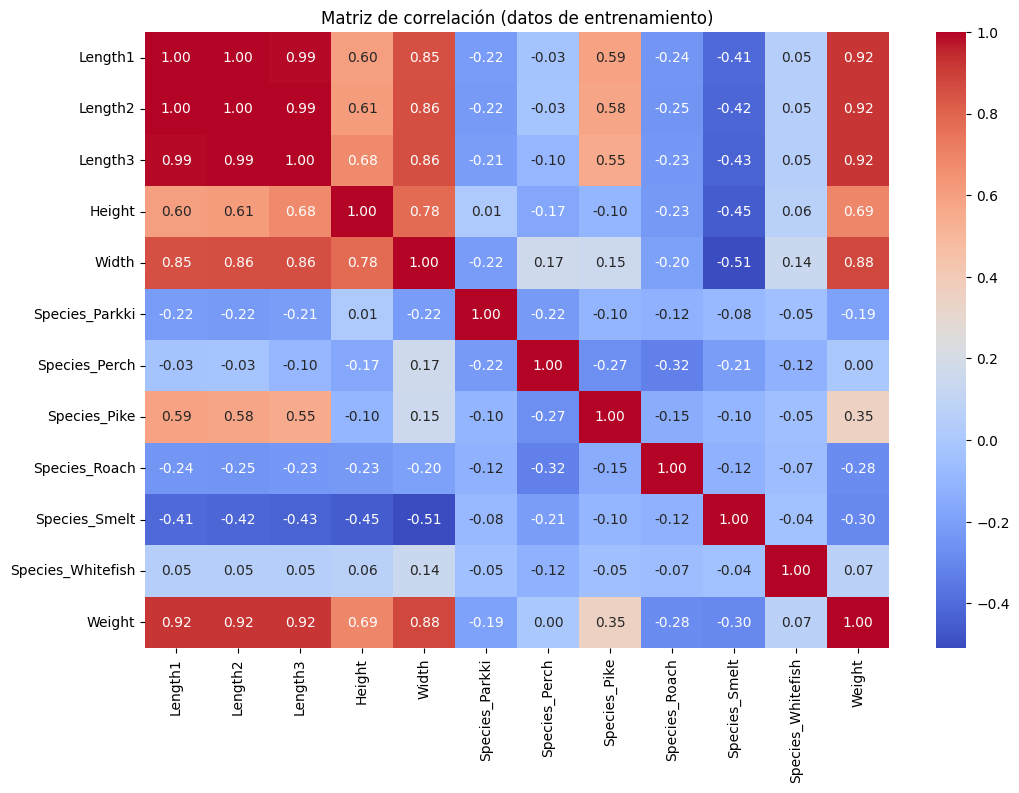

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación (datos de entrenamiento)')
plt.show()

### Integrado (Modelo: RandomForestRegressor)

In [19]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()
rfr.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Importancia de características según Random Forest

In [20]:
importances = rfr.feature_importances_

In [21]:
df_importances = pd.DataFrame({
    'Característica': X_train_scaled.columns,
    'Importancia': importances
}).sort_values(
    by='Importancia',
    ascending=False
)
df_importances

,Característica,Importancia
4,Width,0.729877
2,Length3,0.128772
1,Length2,0.064748
0,Length1,0.063978
3,Height,0.008238
7,Species_Pike,0.003638
10,Species_Whitefish,0.000275
8,Species_Roach,0.000240
6,Species_Perch,0.000190
5,Species_Parkki,0.000029


# Seleccion con umbral

In [22]:
umbral = 0.01
features_rf = df_importances[df_importances['Importancia'] > umbral]['Característica'].tolist()
print("\nCaracterísticas con importancia > 0.01:")
print(features_rf)


Características con importancia > 0.01:
['Width', 'Length3', 'Length2', 'Length1']


## Consenso de características

In [23]:
# Unimos las selecciones de RFECV y Random Forest (intersección).
# Si no hay acuerdo, nos quedamos con la lista más parsimoniosa (RFECV).
consenso = list(set(features_rfecv) & set(features_rf))
if not consenso:
    consenso = features_rfecv
print("Características finales (consenso):")
print(consenso)

Características finales (consenso):
['Length2', 'Length3', 'Length1']


### Entrenamiento del modelo final (usando solo las variables seleccionadas)

In [24]:
# Filtramos los conjuntos de entrenamiento y prueba
X_train_final = X_train_scaled[consenso]
X_test_final  = X_test_scaled[consenso]

 ### Modelo Ridge

In [25]:
modelo_final = Ridge(alpha=1.0)
modelo_final.fit(X_train_final, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### Predicción

In [26]:
y_pred = modelo_final.predict(X_test_final)
y_pred

array([  70.06794771, -104.91353638,  497.8285906 ,  314.16900252,
        208.94368377,  678.76021503, -158.78807337,  293.98335914,
        257.77180992, 1209.44698489,  573.52526857,  738.9735385 ,
        528.74196636,  135.6723538 ,  619.83926719,  723.11006593,
        824.63963098,  314.59392574,  238.51025105,  559.83015215,
       -118.74333711,  571.57019875,  510.2607298 ,  496.60408967,
        721.58844742,  811.59015257,  223.72696741,  330.47390467,
       -182.44132719, -118.74333711,  806.14876672,   38.58478692])

# Evaluación del modelo

### Error absoluto medio

In [27]:
from sklearn.metrics import mean_absolute_error
mae  = mean_absolute_error(y_test, y_pred)
print(f"MAE(mean_absolute_error): {mae:.2f} gramos")


MAE(mean_absolute_error): 119.58 gramos


### Error cuadratico medio

In [28]:
import numpy as np
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MSE(mean_squared_error): {mse:.2f}")
print(f"RMSE: {rmse:.2f} gramos")

MSE(mean_squared_error): 23316.59
RMSE: 152.70 gramos


### r2 (coeficiente de determinación)

In [29]:
from sklearn.metrics import  r2_score
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")

R²: 0.8361


In [30]:
import joblib

paquete_modelo = {
    "modelo": modelo_final,
    "escalador": scaler,
    "columnas_originales": col_names,
    "caracteristicas": consenso
}

joblib.dump(paquete_modelo, "modelo_peso_peces.pkl")

['modelo_peso_peces.pkl']